# ANÁLISIS DEL DATASET TITANIC 
## 1. IMPORTAR LIBRERÍAS

In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
import joblib  # Para guardar el modelo


## 2. CARGA Y EXPLORACIÓN (EDA)

### Cargar dataset

In [2]:
df = pd.read_csv('Titanic.csv')

### Mostrar estructura básica

In [3]:
print("Primeras filas del dataset:")
print(df.head())

Primeras filas del dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450 

### Ver valores faltantes

In [4]:
print("\nValores faltantes:")
print(df.isnull().sum())


Valores faltantes:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Visualizar distribución de supervivientes

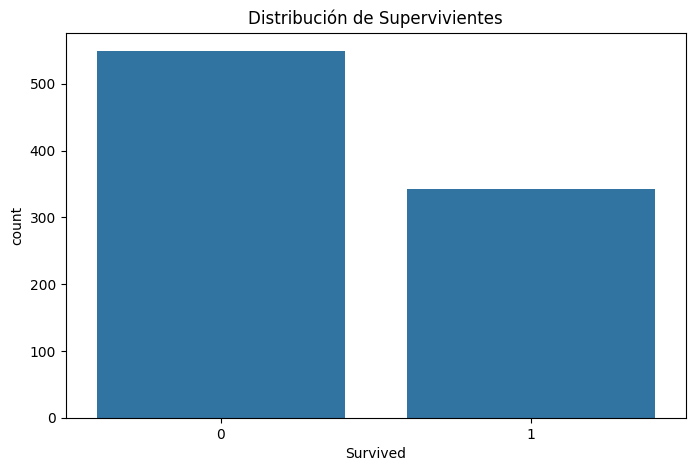

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(x='Survived', data=df)
plt.title('Distribución de Supervivientes')
plt.show()

## 3. PREPROCESAMIENTO DE DATOS

**SibSp**

Significado: Sibling + Spouse (Hermanos + Cónyuge).

Qué representa:
- Número de hermanos/hermanas (siblings) a bordo.
- Número de esposos/esposas (spouses) a bordo.

Ejemplo:

>SibSp = 1 → El pasajero viajaba con 1 hermano/hermana o con su esposo/esposa.

**Parch**

Significado: Parent + Child (Padres + Hijos).

Qué representa:
* Número de hijos/hijas (children) a bordo.
- Número de padres/madres (parents) a bordo.

Ejemplo:

>Parch = 2 → El pasajero viajaba con 2 hijos o con 1 padre y 1 madre.

### Crear nuevas caracteristicas 

In [6]:
df['family_size'] = df['SibSp'] + df['Parch']
df['is_alone'] = (df['family_size'] == 0).astype(int)

## Eliminar columnas no útiles

In [7]:
df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1, inplace=True)

### Definir variables para el modelo

In [8]:
cat_vars = ['Sex','Embarked','Pclass']  # Categóricas
num_vars = ['Age','Fare','SibSp','Parch','family_size','is_alone']  # Numéricas

### Pipeline para variables numéricas

In [9]:

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Imputar faltantes con mediana
    ('scaler', StandardScaler())  # Estandarizar valores
])


### Por que hay que estandarizar valores?

Media = 0 y Desviación Estándar = 1  
Imagina que estás comparando las edades (Age) y los precios de los tickets (Fare) de los pasajeros del Titanic. Estos datos están en escalas totalmente diferentes:

- Edad: Entre 0 y 80 años (valores pequeños).
- Precio del ticket: Entre £0 y £500 (valores grandes).

Si usas estos datos directamente en un modelo de machine learning (como una regresión logística para predecir supervivencia), el modelo podría darle más importancia al precio del ticket solo porque sus números son más grandes, incluso si la edad es más relevante para predecir quién sobrevivió. Aquí es donde entra la estandarización (StandardScaler).

¿Qué hace StandardScaler?
Transforma tus datos para que:

- Media = 0: El valor promedio de todos los datos se centra en cero.
- Desviación estándar = 1: La dispersión de los datos se ajusta a una escala uniforme.

### Pipeline para variables categóricas

In [10]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Usa la moda (ej: 'S' en Embarked)
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Convierte Sex (male/female) a 0/1
])

### Combinar transformaciones

In [11]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_vars),
        ('cat', categorical_transformer, cat_vars)
    ])


## 4. PREPARACIÓN DE DATOS
### Separar variables predictoras (X) y objetivo (y)

In [12]:

X = df.drop('Survived', axis=1)
y = df['Survived']


### Dividir en train (80%) y test (20%)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## 5. CREACIÓN Y ENTRENAMIENTO DE MODELOS
### Pipeline para Regresión Logística

In [14]:

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])


### Entrenar modelo REGRESION LOGISTICA

In [15]:

logreg_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Pipeline para RAMDOM FOREST

In [16]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

### Entrenar modelo

In [17]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 6. EVALUACIÓN DE MODELOS

In [18]:



def evaluar_modelo(modelo, X_test, y_test):
    """Función para evaluar y mostrar métricas de un modelo"""
    # Predecir valores
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:,1]
    
    # Mostrar reporte de clasificación
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))
    
    # Mostrar matriz de confusión
    plt.figure(figsize=(8,6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Sobrevivió', 'Sobrevivió'],
                yticklabels=['No Sobrevivió', 'Sobrevivió'])
    plt.title('Matriz de Confusión')
    plt.show()
    
    # Mostrar ROC AUC
    print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")



### Evaluar Regresión Logística


EVALUACIÓN REGRESIÓN LOGÍSTICA

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



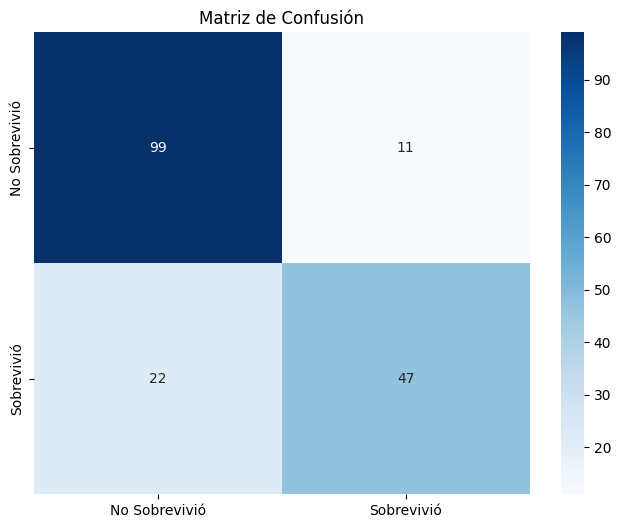

ROC AUC: 0.8506


In [19]:
print("\nEVALUACIÓN REGRESIÓN LOGÍSTICA")
evaluar_modelo(logreg_pipeline, X_test, y_test)

### Evaluar Random Forest


EVALUACIÓN RANDOM FOREST

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



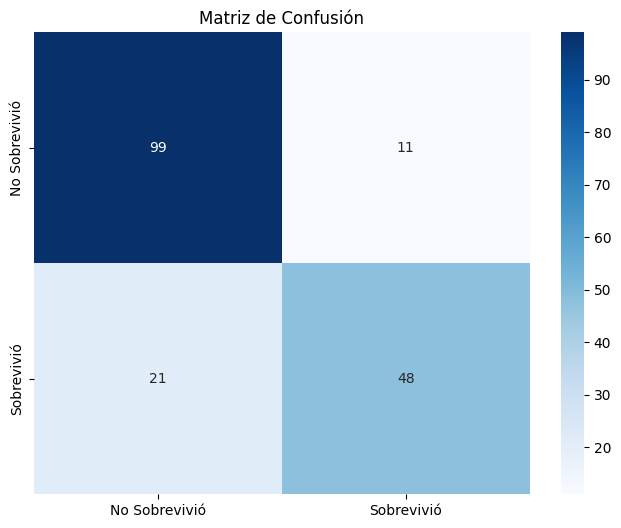

ROC AUC: 0.8220


In [20]:

print("\nEVALUACIÓN RANDOM FOREST")
evaluar_modelo(rf_pipeline, X_test, y_test)

## 7. OPTIMIZACIÓN DE HIPERPARÁMETROS (Opcional)
### Definir parámetros a probar

In [21]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],  # Parámetro de regularización
    'classifier__solver': ['liblinear', 'lbfgs']  # Algoritmo de optimización
}

### Configurar búsqueda

In [22]:
grid_search = GridSearchCV(
    logreg_pipeline,
    param_grid,
    cv=5,  # Validación cruzada de 5 folds
    scoring='roc_auc',
    n_jobs=-1  # Usar todos los núcleos del CPU
)

### Ejecutar búsqueda

In [23]:
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__C': [0.01, 0.1, ...], 'classifier__solver': ['liblinear', 'lbfgs']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


### Mostrar mejores parámetros

In [24]:
print(f"\nMejores parámetros: {grid_search.best_params_}")
print(f"Mejor ROC AUC: {grid_search.best_score_:.4f}")


Mejores parámetros: {'classifier__C': 1, 'classifier__solver': 'liblinear'}
Mejor ROC AUC: 0.8559


### Evaluar mejor modelo


EVALUACIÓN MEJOR MODELO

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



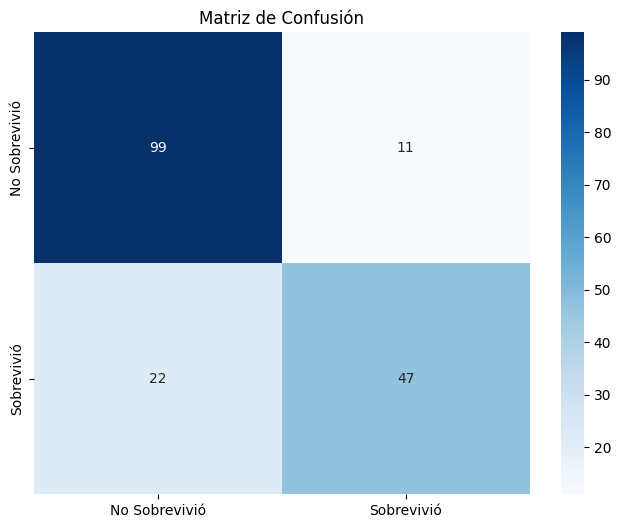

ROC AUC: 0.8506


In [25]:
best_model = grid_search.best_estimator_
print("\nEVALUACIÓN MEJOR MODELO")
evaluar_modelo(best_model, X_test, y_test)

## 8. GUARDAR MODELO (Opcional)

In [ ]:
joblib.dump(best_model, 'mejor_modelo_titanic.pkl')
print("Modelo guardado como 'mejor_modelo_titanic.pkl'")

### Curva ROC

La curva ROC (Receiver Operating Characteristic) muestra cómo cambia el rendimiento del modelo cuando se ajusta el umbral de decisión.
- El eje X representa la tasa de falsos positivos.
- El eje Y representa la tasa de verdaderos positivos o recall.
- Mientras más cerca esté la curva de la esquina superior izquierda, mejor separa el modelo las clases.
- El área bajo la curva (AUC) resume ese rendimiento: cuanto más cerca de 1, mejor.

Esta gráfica sirve para ver si el modelo distingue bien entre quienes sobrevivieron y quienes no, no solo con una sola métrica.

In [ ]:
from sklearn.metrics import roc_curve, auc

# Probabilidades de la clase positiva
# Usamos el mejor modelo ya entrenado en el notebook
y_prob = best_model.predict_proba(X_test)[:, 1]

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Dibujar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC - Mejor modelo Titanic')
plt.legend(loc='lower right')
plt.show()